**Category 1:Elastic nets**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNetCV
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Simulated data
X, y = make_regression(n_samples=500, n_features=20, noise=0.1, random_state=42)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Elastic Net with cross-validation
elastic = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],  # grid of alpha
                       alphas=np.logspace(-3, 1, 50),            # grid of lambdas
                       cv=5,
                       random_state=42)

elastic.fit(X_train, y_train)
print("Best alpha :", elastic.alpha_)
print("Best l1_ratio (α):", elastic.l1_ratio_)
print("R^2 on test:", elastic.score(X_test, y_test))

Best alpha : 0.0021209508879201904
Best l1_ratio (α): 1.0
R^2 on test: 0.9999994275069372


****

**CATEGORY 2: K-Means Clustering**


In [ ]:
!pip install yfinance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import yfinance as yf
import warnings

In [ ]:
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","JPM","BAC","WMT","PG","KO",
    "XOM","CVX","TSLA","NVDA","INTC","CSCO","ADBE","ORCL","NKE","MCD"
]  # sample 20 US large caps
lookback_days = 252 * 2  # two years of daily returns
end_date = None  # today
start_date = None

In [ ]:
# download prices and compute log returns
data = yf.download(tickers, period="3y", interval="1d", progress=False, auto_adjust=False )["Adj Close"]
data = data.dropna(axis=1, how='any')  # drop tickers with missing data
prices = data.ffill().dropna()
returns = np.log(prices).diff().dropna()
# Trim to lookback
returns = returns.tail(lookback_days)
returns.shape

(504, 20)

In [ ]:
# correlation and correlation distance
corr = returns.corr()  # Pearson correlation
# correlation distance as commonly used:
dist_corr = np.sqrt(0.5 * (1 - corr))
# convert to condensed distance matrix for scipy hierarchical methods
condensed_dist = squareform(dist_corr.values, checks=False)


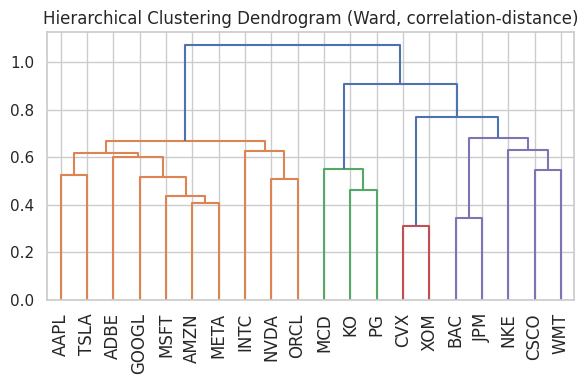

In [ ]:
# hierarchical clustering (Ward) and dendrogram
Z = linkage(condensed_dist, method="ward")  # ward on distance matrix
plt.figure(figsize=(6, 4))
dendro = dendrogram(Z, labels=corr.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward, correlation-distance)")
plt.tight_layout()
plt.show()


In [ ]:
# choose number of clusters from dendrogram/ specify K
K_from_dendrogram = 5
labels_hier = fcluster(Z, K_from_dendrogram, criterion="maxclust")
cluster_map_hier = pd.Series(labels_hier, index=corr.index, name="cluster_hier")
print(cluster_map_hier.value_counts().sort_index())


cluster_hier
1    10
2     3
3     2
4     2
5     3
Name: count, dtype: int64


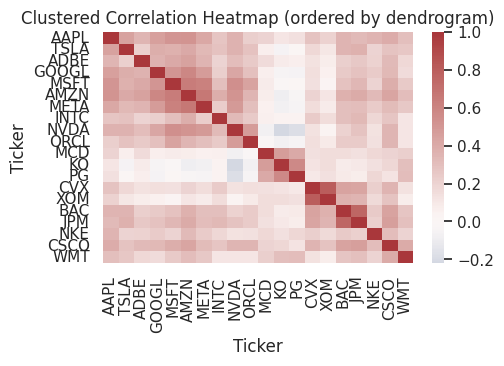

In [ ]:
# clustered correlation heatmap
order = dendro['leaves']  # order of tickers from dendrogram
ordered_tickers = [corr.index[i] for i in order]
corr_ordered = corr.loc[ordered_tickers, ordered_tickers]

plt.figure(figsize=(5, 3))
sns.heatmap(corr_ordered, cmap="vlag", center=0, xticklabels=True, yticklabels=True)
plt.title("Clustered Correlation Heatmap (ordered by dendrogram)")
plt.show()


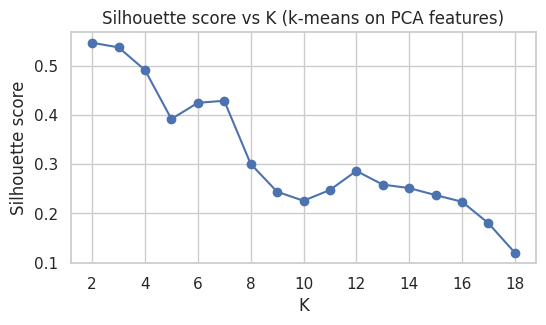

best K by silhouette: 2


In [ ]:
# k-means on PCA-reduced returns (common pipeline)
# Standard approach: reduce dimensionality (PCA) then kmeans on leading PCs
pca = PCA(n_components=5)
X_pca = pca.fit_transform(returns.T)  # assets x features -> shape (n_assets, n_components)

# iterate K candidates using silhouette
sil_scores = {}
# The number of clusters must be less than the number of samples (tickers).
K_range = range(2, len(returns.T) -1 )
for K in K_range:
    km = KMeans(n_clusters=K, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    sil_scores[K] = sil

# plot silhouette vs K
plt.figure(figsize=(6,3))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs K (k-means on PCA features)")
plt.show()

best_K = max(sil_scores, key=sil_scores.get)
print("best K by silhouette:", best_K)

In [ ]:
# k-means clustering and cluster summary
km = KMeans(n_clusters=best_K, n_init=100, random_state=42)
labels_km = km.fit_predict(X_pca)
cluster_map_km = pd.Series(labels_km+1, index=returns.columns, name="cluster_kmeans")  # +1 to make 1..K
cluster_map_km.value_counts().sort_index()


,count
cluster_kmeans,
1,19
2,1


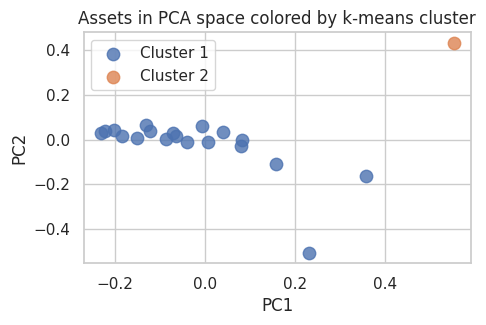

In [ ]:
# 2D projection of assets by first 2 PCs colored by cluster
plt.figure(figsize=(5,3))
for c in np.unique(labels_km):
    idx = np.where(labels_km==c)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=f"Cluster {c+1}", s=80, alpha=0.8)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Assets in PCA space colored by k-means cluster")
plt.legend()
plt.show()


In [ ]:
# cluster-level return/volatility statistics (on historical returns)
summary = []
for cl in sorted(cluster_map_km.unique()):
    assets = cluster_map_km[cluster_map_km==cl].index
    r = returns[assets].mean(axis=1)
    summary.append({
        "cluster": cl,
        "n_assets": len(assets),
        "avg_daily_ret": r.mean(),
        "ann_ret": r.mean()*252,
        "ann_vol": r.std()*np.sqrt(252),
        "sharpe": (r.mean()*252)/(r.std()*np.sqrt(252)+1e-9)
    })
summary_df = pd.DataFrame(summary).set_index("cluster")
summary_df


,n_assets,avg_daily_ret,ann_ret,ann_vol,sharpe
cluster,,,,,
1,19,0.000756,0.190441,0.161396,1.179962
2,1,0.000873,0.220027,0.624720,0.352201


**CATEGORY 4: Classification Trees**

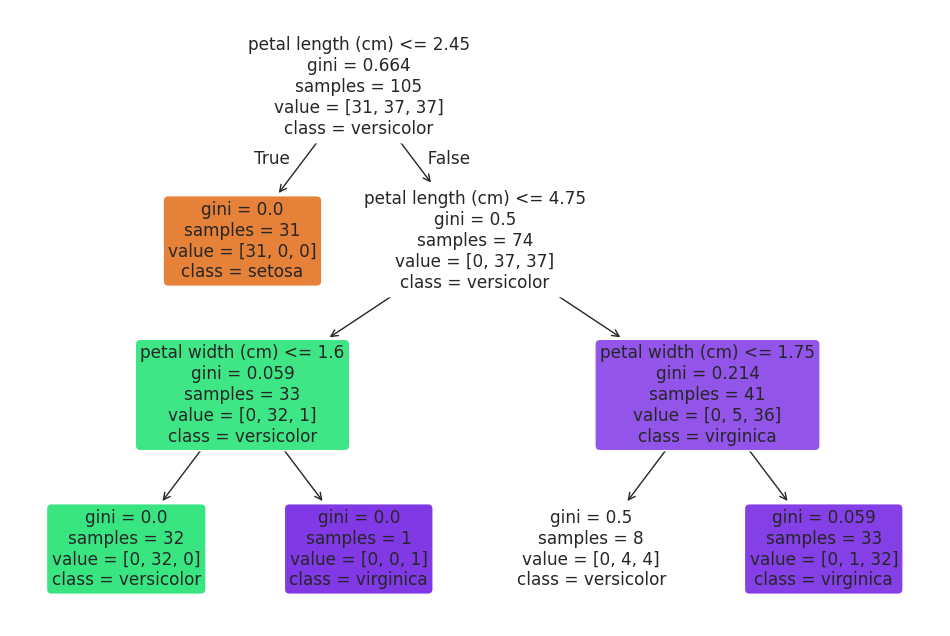

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# Classification Trees - Jupyter Notebook Example
# -----------------------------------------------
# This notebook illustrates how a classification tree works
# using the Iris dataset as an example.

# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Step 2: Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for better readability
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.head()

# Step 3: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 4: Train the classification tree
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Step 5: Visualize the classification tree
plt.figure(figsize=(12,8))
plot_tree(clf,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True)
plt.show()

# Step 6: Make predictions
y_pred = clf.predict(X_test)

# Step 7: Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Sample Data:
   Customer_Age  Monthly_Spend  Tenure_Months  Support_Calls  Churn
0            25             40              3              1      1
1            45             90             24              4      0
2            33             65             12              2      1
3            50            120             36              5      0
4            29             50              6              1      1


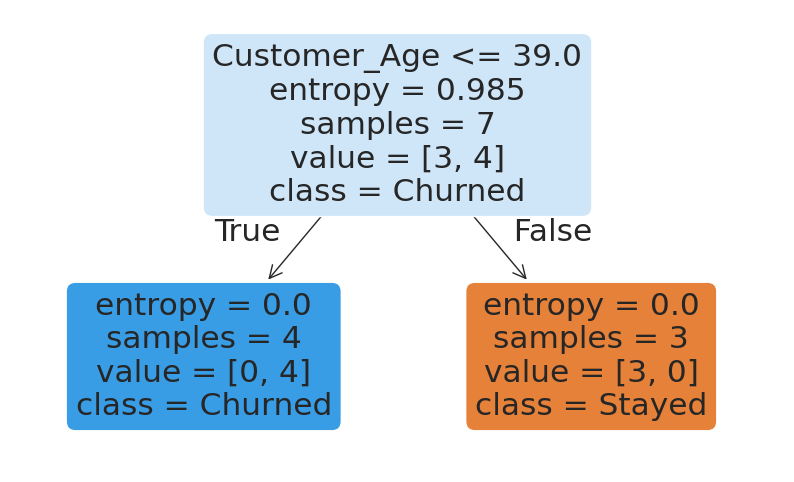

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00         2
     Churned       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
# Customer Churn Prediction using Classification Trees
# ----------------------------------------------------
# This notebook demonstrates how classification trees can be applied
# in a marketing context (predicting whether a customer will churn).

# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Load dataset
# If you have the Kaggle dataset, replace the path below:
# df = pd.read_csv("Telco-Customer-Churn.csv")

# For demonstration, we'll create a smaller synthetic dataset
data = {
    "Customer_Age": [25, 45, 33, 50, 29, 62, 41, 37, 23, 48],
    "Monthly_Spend": [40, 90, 65, 120, 50, 130, 80, 70, 35, 110],
    "Tenure_Months": [3, 24, 12, 36, 6, 48, 20, 18, 2, 30],
    "Support_Calls": [1, 4, 2, 5, 1, 6, 3, 2, 0, 4],
    "Churn": [1, 0, 1, 0, 1, 0, 0, 1, 1, 0]  # 1 = churn, 0 = stayed
}
df = pd.DataFrame(data)

print("Sample Data:")
print(df.head())

# Step 3: Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 5: Train classification tree
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Step 6: Visualize the tree
plt.figure(figsize=(10,6))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["Stayed", "Churned"],
          filled=True,
          rounded=True)
plt.show()

# Step 7: Predictions
y_pred = clf.predict(X_test)

# Step 8: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Downloaded dataset via KaggleHub.
Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4   

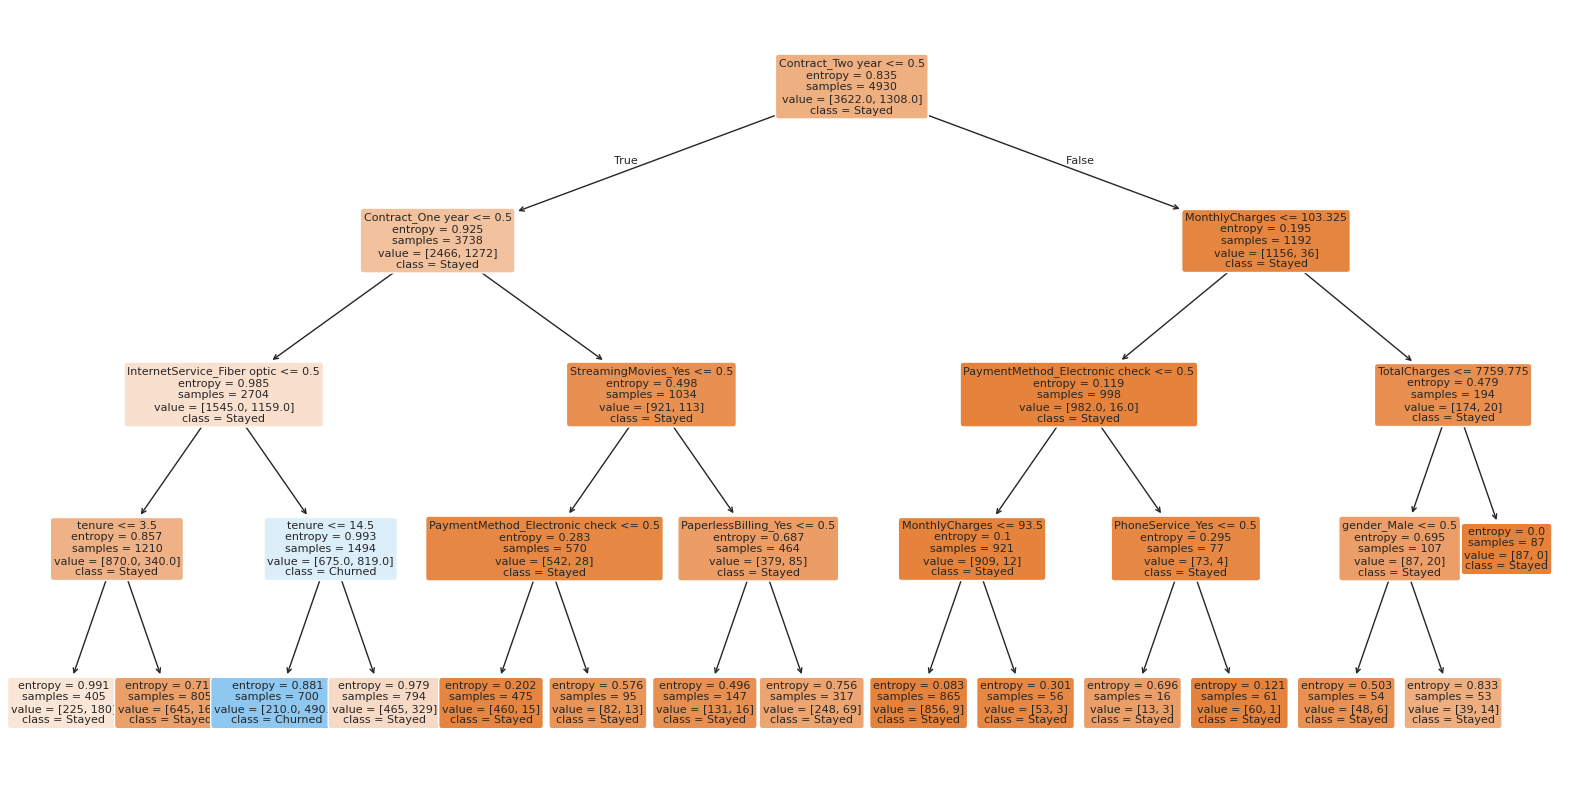

Accuracy on test set: 0.7875059157595835

Classification Report:

              precision    recall  f1-score   support

      Stayed       0.80      0.94      0.87      1552
     Churned       0.69      0.36      0.47       561

    accuracy                           0.79      2113
   macro avg       0.75      0.65      0.67      2113
weighted avg       0.77      0.79      0.76      2113


Top 10 Features Influencing Churn:

                           Feature  Importance
25               Contract_Two year    0.386092
24               Contract_One year    0.254277
1                           tenure    0.133098
10     InternetService_Fiber optic    0.130609
23             StreamingMovies_Yes    0.031684
2                   MonthlyCharges    0.022779
3                     TotalCharges    0.016857
28  PaymentMethod_Electronic check    0.012394
26            PaperlessBilling_Yes    0.005630
7                 PhoneService_Yes    0.003811


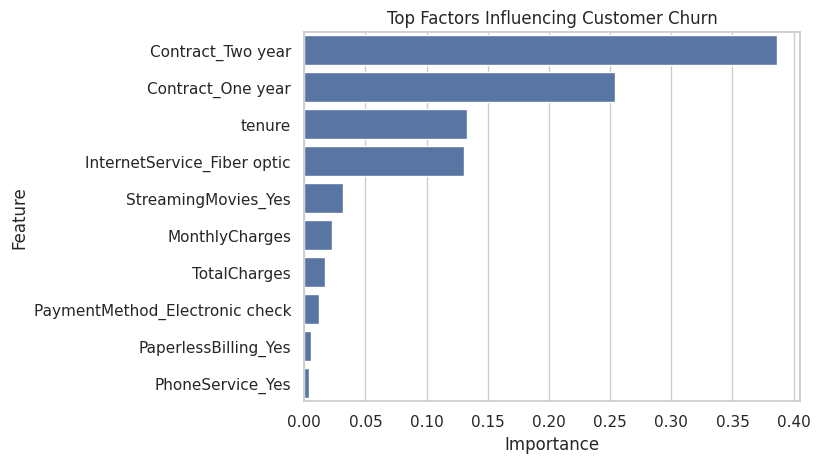

In [ ]:
# Customer Churn Prediction using Classification Trees
# ----------------------------------------------------
# This notebook demonstrates how classification trees can be applied
# in a marketing context (predicting whether a customer will churn).

# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import os

# Step 2: Try downloading dataset from Kaggle using kagglehub
try:
    import kagglehub
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    dataset_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print("Downloaded dataset via KaggleHub.")
except Exception as e:
    print("KaggleHub download failed:", e)
    # Fallback: look for local CSV file in working directory
    dataset_file = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
    if os.path.exists(dataset_file):
        print("Loaded dataset from local CSV file.")
    else:
        raise FileNotFoundError(
            "Dataset not found. Please place 'WA_Fn-UseC_-Telco-Customer-Churn.csv' "
            "in your working directory."
        )

# Step 3: Load the dataset
df = pd.read_csv(dataset_file)

print("Dataset shape:", df.shape)
print(df.head())

# Step 4: Data preprocessing
# Drop customerID since it's just an identifier
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric (it may contain blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encode target variable: Churn (Yes=1, No=0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 5: Split into features (X) and target (y)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 6: Train a classification tree
clf = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Step 7: Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["Stayed", "Churned"],
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

# Step 8: Evaluate model performance
y_pred = clf.predict(X_test)

print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

# Step 9: Feature importance (marketing insight)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Features Influencing Churn:\n")
print(feature_importance.head(10))

sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top Factors Influencing Customer Churn")
plt.show()

****

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy: 0.7892494929006085

Test Set Accuracy: 0.7879791765262659

Classification Report (Tuned Model):

              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1552
     Churned       0.62      0.52      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



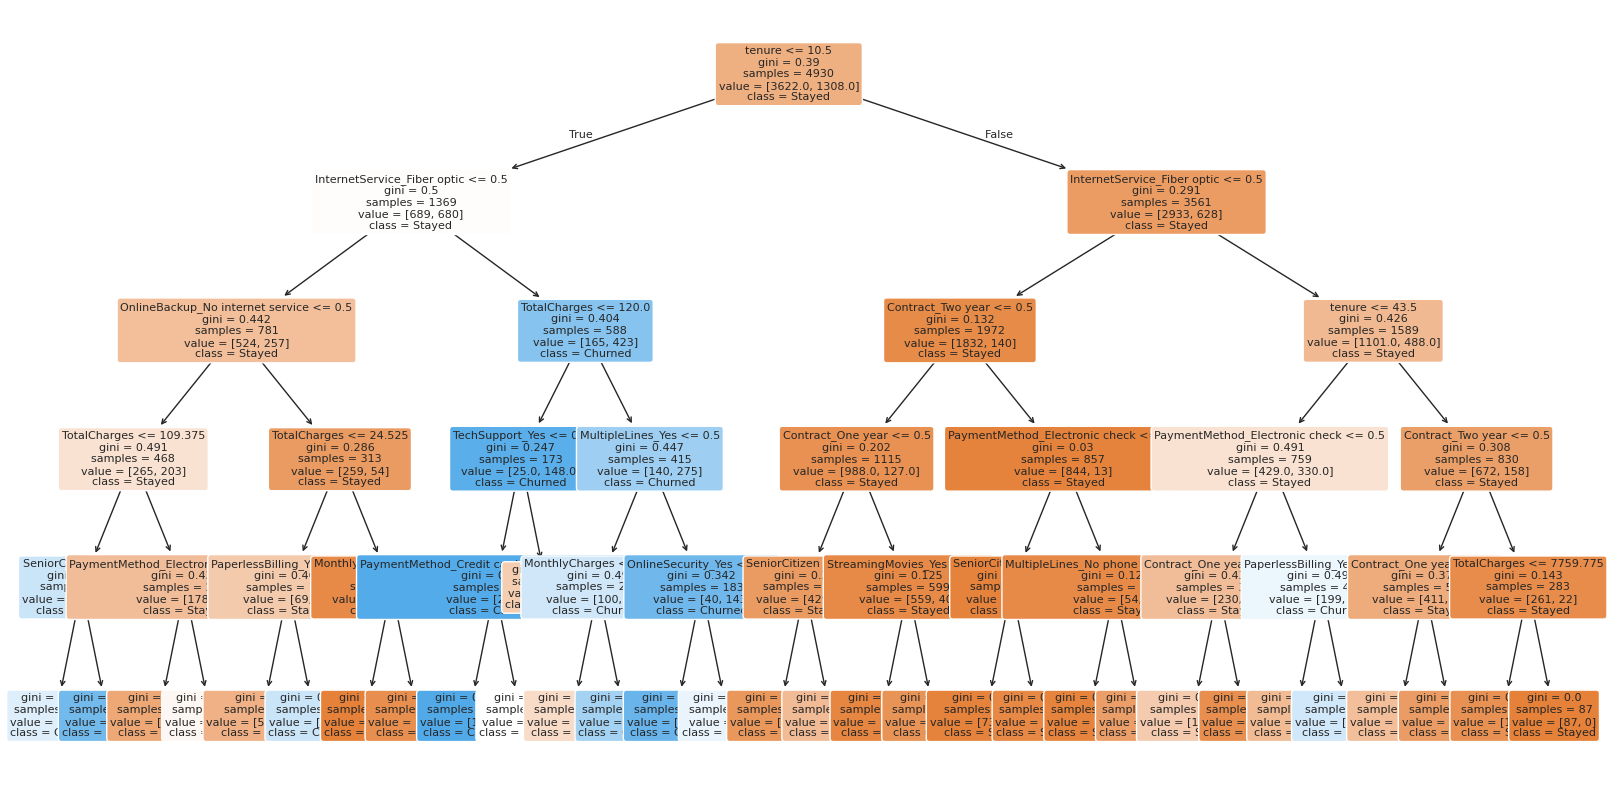


Top 10 Features Influencing Churn (Tuned Model):

                             Feature  Importance
1                             tenure    0.403541
10       InternetService_Fiber optic    0.322926
3                       TotalCharges    0.061136
14  OnlineBackup_No internet service    0.041266
28    PaymentMethod_Electronic check    0.037132
25                 Contract_Two year    0.032788
24                 Contract_One year    0.031053
26              PaperlessBilling_Yes    0.018688
9                  MultipleLines_Yes    0.014887
2                     MonthlyCharges    0.010076


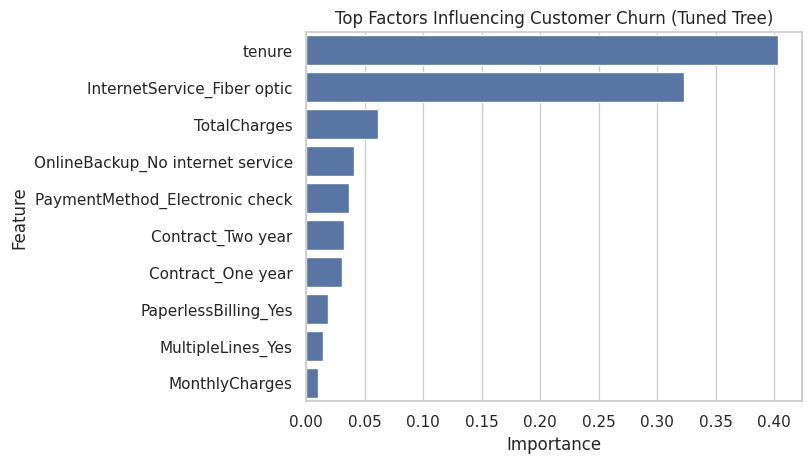

In [ ]:
# Step 6: Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# Initialize base model
dtree = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Step 7: Retrain with best parameters
best_dtree = grid_search.best_estimator_
best_dtree.fit(X_train, y_train)

# Step 8: Evaluate tuned model
y_pred_best = best_dtree.predict(X_test)

print("\nTest Set Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"]))

# Step 9: Visualize tuned decision tree
plt.figure(figsize=(20,10))
plot_tree(best_dtree,
          feature_names=X.columns,
          class_names=["Stayed", "Churned"],
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

# Step 10: Feature importance from tuned model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dtree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Features Influencing Churn (Tuned Model):\n")
print(feature_importance.head(10))

sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top Factors Influencing Customer Churn (Tuned Tree)")
plt.show()

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Parameters (GridSearchCV): {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy (GridSearchCV): 0.7892494929006085
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters (RandomizedSearchCV): {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 17, 'min_samples_split': 18}
Best CV Accuracy (RandomizedSearchCV): 0.7937119675456389

Test Set Accuracy: 0.7917652626597255

Classification Report (Tuned Model):

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1552
     Churned       0.64      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



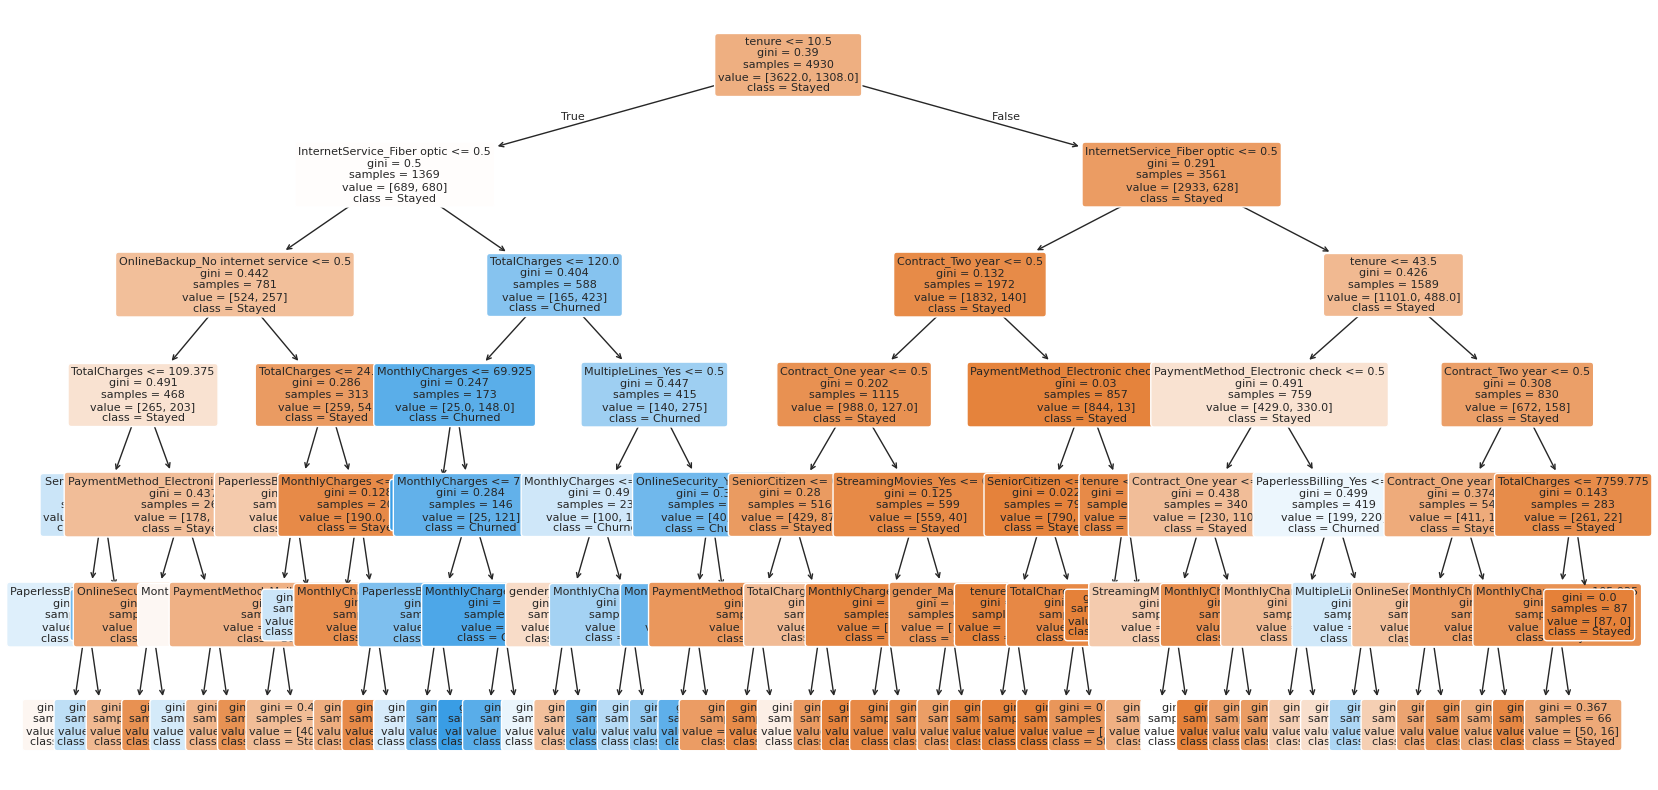


Top 10 Features Influencing Churn (Tuned Model):

                             Feature  Importance
1                             tenure    0.376725
10       InternetService_Fiber optic    0.300809
3                       TotalCharges    0.061790
2                     MonthlyCharges    0.039537
14  OnlineBackup_No internet service    0.038440
28    PaymentMethod_Electronic check    0.034589
25                 Contract_Two year    0.030543
24                 Contract_One year    0.028926
9                  MultipleLines_Yes    0.023331
26              PaperlessBilling_Yes    0.021759


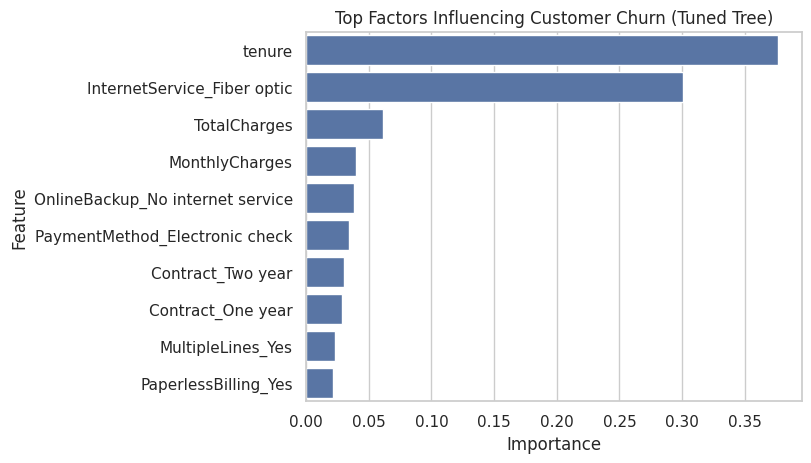

In [ ]:
# ================================
# Step 6A: Hyperparameter tuning with GridSearchCV
# ================================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Define parameter grid for GridSearchCV
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

dtree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters (GridSearchCV):", grid_search.best_params_)
print("Best CV Accuracy (GridSearchCV):", grid_search.best_score_)


# ================================
# Step 6B: Hyperparameter tuning with RandomizedSearchCV
# ================================

# Define distributions for RandomizedSearchCV
param_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None] + list(range(3, 15)),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=dtree,
    param_distributions=param_dist,
    n_iter=50,          # number of random combinations to try
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best CV Accuracy (RandomizedSearchCV):", random_search.best_score_)


# ================================
# Step 7: Retrain with best parameters (choose one approach)
# ================================

# You can pick either the grid search or random search best estimator
best_dtree = random_search.best_estimator_  # or grid_search.best_estimator_
best_dtree.fit(X_train, y_train)

# Step 8: Evaluate tuned model
y_pred_best = best_dtree.predict(X_test)

print("\nTest Set Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"]))

# Step 9: Visualize tuned decision tree
plt.figure(figsize=(20,10))
plot_tree(best_dtree,
          feature_names=X.columns,
          class_names=["Stayed", "Churned"],
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

# Step 10: Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dtree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Features Influencing Churn (Tuned Model):\n")
print(feature_importance.head(10))

sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top Factors Influencing Customer Churn (Tuned Tree)")
plt.show()

**FOOTNOTE**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.